# [Real or Fake] : Fake Job Description Prediction

This dataset contains 18K job descriptions out of which about 800 are fake. The data consists of both textual information and meta-information about the jobs. The dataset can be used to create classification models which can learn the job descriptions which are fraudulent.

This file contains the dataset of job descriptions and their meta information. A small proportion of these descriptions are fake or scam which can be identified by the column "fraudulent".




In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')

### Data Loading

In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv(r"D:\admin\Documents\fake_job_postings.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset shape: (17880, 18)

Columns:
['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


### Check Target Variable

In [2]:
print(df["fraudulent"].value_counts())

print("\nPercentage:")
print(df["fraudulent"].value_counts(normalize=True) * 100)

fraudulent
0    17014
1      866
Name: count, dtype: int64

Percentage:
fraudulent
0    95.1566
1     4.8434
Name: proportion, dtype: float64


### Feature Selection

In [3]:
text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

# Replace missing values with empty strings
df[text_columns] = df[text_columns].fillna("")

# Combine all text columns
df["combined_text"] = df[text_columns].agg(" ".join, axis=1)

df[["combined_text", "fraudulent"]].head()

,combined_text,fraudulent
0,"Marketing Intern We're Food52, and we've creat...",0
1,Customer Service - Cloud Video Production 90 S...,0
2,Commissioning Machinery Assistant (CMA) Valor ...,0
3,Account Executive - Washington DC Our passion ...,0
4,Bill Review Manager SpotSource Solutions LLC i...,0


### Basic Text Cleaning

In [4]:
import re
import html

def clean_text(text):
    text = str(text)
    
    # Convert HTML entities
    text = html.unescape(text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

df["clean_text"] = df["combined_text"].apply(clean_text)

df[["combined_text", "clean_text"]].head()

,combined_text,clean_text
0,"Marketing Intern We're Food52, and we've creat...",marketing intern we re food and we ve created ...
1,Customer Service - Cloud Video Production 90 S...,customer service cloud video production second...
2,Commissioning Machinery Assistant (CMA) Valor ...,commissioning machinery assistant cma valor se...
3,Account Executive - Washington DC Our passion ...,account executive washington dc our passion fo...
4,Bill Review Manager SpotSource Solutions LLC i...,bill review manager spotsource solutions llc i...


### NLP Preprocessing

In [5]:
import nltk

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [6]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    words = text.split()
    
    # Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]
    
    # Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]
    
    return " ".join(words)

df["processed_text"] = df["clean_text"].apply(preprocess_text)

df[["clean_text", "processed_text"]].head()

,clean_text,processed_text
0,marketing intern we re food and we ve created ...,marketing intern food created groundbreaking a...
1,customer service cloud video production second...,customer service cloud video production second...
2,commissioning machinery assistant cma valor se...,commissioning machinery assistant cma valor se...
3,account executive washington dc our passion fo...,account executive washington dc passion improv...
4,bill review manager spotsource solutions llc i...,bill review manager spotsource solution llc gl...


### Converting Text into Numerical features using TF- IDF

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X = tfidf.fit_transform(df["processed_text"])
Y = df["fraudulent"]

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (17880, 10000)
Y shape: (17880,)


### Data Splitting

In [10]:
from sklearn.model_selection import train_test_split

# Split the data into test and train
X_train , X_test , Y_train , Y_test = train_test_split(X,Y,test_size = 0.2,random_state = 10)

In [11]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(14304, 10000)
(3576, 10000)
(14304,)
(3576,)


In [12]:
from sklearn.linear_model import LogisticRegression

# create a model object
classifier = LogisticRegression()

# fitting training data to the model object
classifier.fit(X_train,Y_train)   #input

Y_pred = classifier.predict(X_test)
print(Y_pred)

[0 0 0 ... 0 0 0]


In [13]:
#np.set_printoptions(suppress= True)
Y_pred_prob = classifier.predict_proba(X_test)
Y_pred_prob

array([[0.51876222, 0.48123778],
       [0.98100122, 0.01899878],
       [0.95282804, 0.04717196],
       ...,
       [0.98394867, 0.01605133],
       [0.97382059, 0.02617941],
       [0.98953983, 0.01046017]])

In [14]:
np.set_printoptions(suppress= True)
Y_pred_prob = classifier.predict_proba(X_test)
Y_pred_prob

array([[0.51876222, 0.48123778],
       [0.98100122, 0.01899878],
       [0.95282804, 0.04717196],
       ...,
       [0.98394867, 0.01605133],
       [0.97382059, 0.02617941],
       [0.98953983, 0.01046017]])

### Model Evaluation

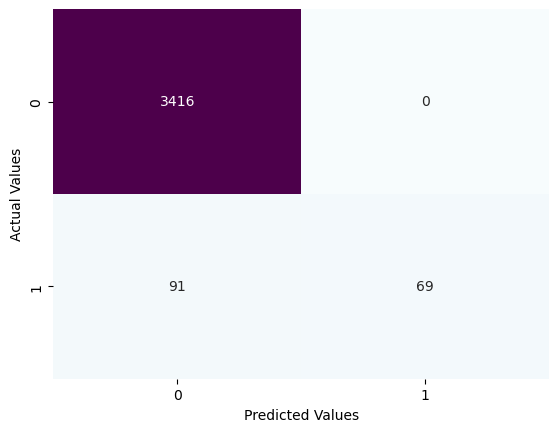

[[3416    0]
 [  91   69]]
Classification report: 
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      3416
           1       1.00      0.43      0.60       160

    accuracy                           0.97      3576
   macro avg       0.99      0.72      0.79      3576
weighted avg       0.98      0.97      0.97      3576

Accuracy of the model:  0.9745525727069351


In [17]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
 
cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm , annot=True , fmt='g' , cbar=False , cmap="BuPu")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()
print(cfm)
 
print("Classification report: ")
print(classification_report(Y_test,Y_pred))
 
acc=accuracy_score(Y_test, Y_pred)
print("Accuracy of the model: ",acc)

In [18]:
# print the scores on training and test set

print('Training set score: {:.4f}'.format(classifier.score(X_train, Y_train)))

print('Test set score: {:.4f}'.format(classifier.score(X_test, Y_test)))

Training set score: 0.9758
Test set score: 0.9746


### Test a new job posting

In [24]:
def predict_job(job_text):
    cleaned = clean_text(job_text)
    processed = preprocess_text(cleaned)
    
    vector = tfidf.transform([processed])
    
    prediction = classifier.predict(vector)[0]
    probability = classifier.predict_proba(vector)[0]
    
    if prediction == 1:
        result = "FAKE / FRAUDULENT JOB POSTING"
    else:
        result = "REAL JOB POSTING"
    
    print("Prediction:", result)
    print("Real probability:", round(probability[0] * 100, 2), "%")
    print("Fake probability:", round(probability[1] * 100, 2), "%")

In [25]:
new_job = """
We are looking for a talented software developer to join our team.
The candidate should have experience with Python, SQL and machine learning.
You will work with our engineering team to develop and maintain software
applications. Bachelor's degree in computer science preferred.
"""

predict_job(new_job)

Prediction: REAL JOB POSTING
Real probability: 97.81 %
Fake probability: 2.19 %


#### Prediction Result:
The proposed NLP-based classification model predicted the given job posting as a real job posting, with a predicted probability of 97.81% for the real class and approximately 2.19% for the fraudulent class.

In [26]:
fake_job = """
URGENT WORK FROM HOME OPPORTUNITY!!!

Earn $5,000 per week working only 2 hours a day!
No experience, education, or interview required.
We are hiring immediately and there are unlimited vacancies.

You must pay a $250 registration and training fee before starting.
Send your bank account details, credit card information, and personal
identification documents to complete registration.

Contact us only through WhatsApp at +1-555-123-4567.
Limited positions available! Act NOW to secure your guaranteed income.
"""

predict_job(fake_job)

Prediction: REAL JOB POSTING
Real probability: 65.47 %
Fake probability: 34.53 %


### Limitations:
The main limitations of this project are dependence on the training dataset, possible false predictions, changing fraud patterns, missing information, class imbalance, and the inability to independently verify whether a company or job posting is genuine. Therefore, the model should be used as a decision-support tool rather than as a final authority.